In [1]:
import pandas as pd
import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_EL = 'ανατολικης μακεδονιας και θρακης'

In [3]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"


greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [4]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [5]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [6]:
nuts2_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ']
nuts2_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."


In [7]:
indexes = []

nuts2 = nuts2_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [8]:
nuts2_gdf.head()

,NAME,KWD_YPES,geometry
0,Αβδήρων,9015,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
1,Αλεξανδρούπολης,9006,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
2,Αμφίπολης,9049,"POLYGON ((24.04143 41.04942, 24.04322 41.04930..."
3,Αρριανών,9019,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."
4,Διδυμοτείχου,9007,"POLYGON ((26.33233 41.51492, 26.33276 41.51469..."


<AxesSubplot:>

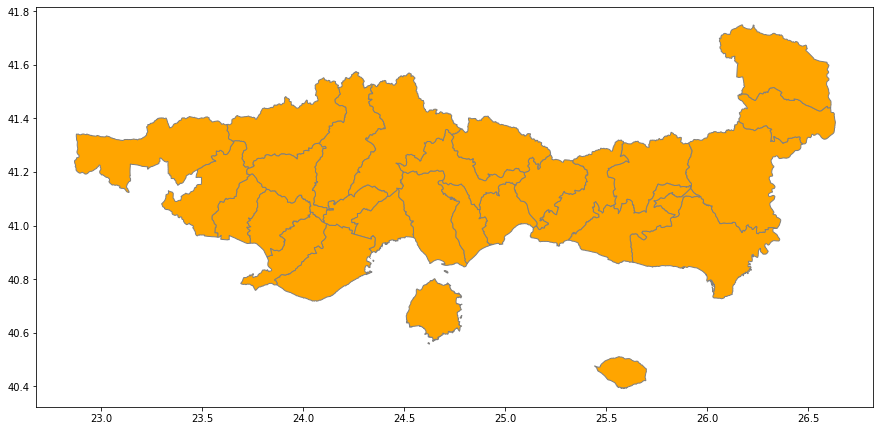

In [9]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [10]:
wrong_list = ['Σιντικής' ,'Σερρών', 'Εμμανουήλ Παππά', 'Νέας Ζίχνης', 'Αμφίπολης']

nuts2_gdf = nuts2_gdf[~nuts2_gdf['NAME'].isin(wrong_list)].copy()

In [11]:
nuts2_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αβδήρων,9015,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
1,Αλεξανδρούπολης,9006,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
3,Αρριανών,9019,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."
4,Διδυμοτείχου,9007,"POLYGON ((26.33233 41.51492, 26.33276 41.51469..."
5,Δοξάτου,9001,"POLYGON ((24.33347 41.14739, 24.33534 41.14657..."


In [12]:
nuts2_gdf.drop(columns=['KWD_YPES'], inplace = True)
nuts2_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(nuts2_gdf, 'lau1')

In [13]:
nuts2_gdf.head(5)

,lau1,geometry
0,αβδηρων,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
1,αλεξανδρουπολης,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
3,αρριανων,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."
4,διδυμοτειχου,"POLYGON ((26.33233 41.51492, 26.33276 41.51469..."
5,δοξατου,"POLYGON ((24.33347 41.14739, 24.33534 41.14657..."


<AxesSubplot:>

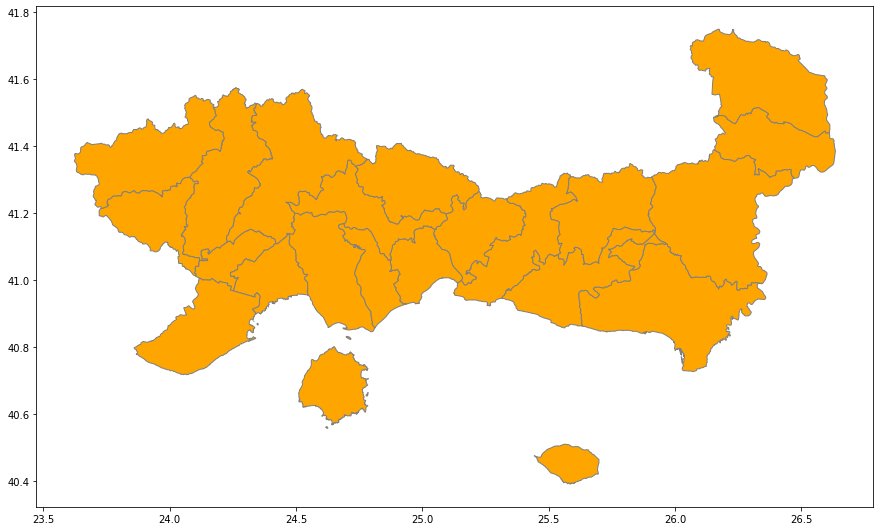

In [14]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [15]:
indexes = []

region = nuts2_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in region.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [16]:
nuts2_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,1,None,ÑÅÌÁ ÍÉÊÇÔÙÍ,REMA NIKHTVN,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,3035.444622,"LINESTRING (25.74206 41.10802, 25.74160 41.107..."
1,1,None,ÑÅÌÁ ÍÉÊÇÔÙÍ,REMA NIKHTVN,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,3035.444622,"LINESTRING (25.74206 41.10802, 25.74160 41.107..."
2,2,GR0012000400300270N,ÐËÁÔÕÑÅÌÌÁ Ñ.,PLATYRREMA S.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,17558.809512,"LINESTRING (25.75701 41.20519, 25.75759 41.204..."
3,4,None,ÌÁÕÑÏÑÑÅÌÁ,MAYRORREMA,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,6849.963018,"LINESTRING (26.26720 41.07231, 26.26821 41.071..."
4,6,GR0012000400250110N,ËÁÓÐÏÔÏÐÏÓ Ñ.,LASPOPOTAMOS S.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,4937.957249,"LINESTRING (24.86379 41.04296, 24.86541 41.041..."


<AxesSubplot:>

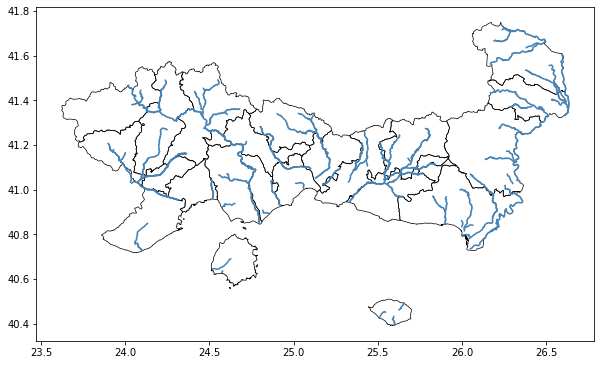

In [17]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(10, 10), cmap='jet', color='steelblue')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [18]:
lau1_units = nuts2_gdf['lau1'].unique().tolist()

with open(f'data/{NUTS0}_SHP_{NUTS2}_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in lau1_units:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in {NUTS2} (from shapefile): {len(lau1_units)}")

Number of LAU1 Units in Thrace (from shapefile): 22


In [19]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [20]:
df_grid = create_grid(nuts2_rivers_gdf, nuts2_gdf, col_municipal='lau1', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

e:\Google Drive\NOA\MBD-Prediction\Greece\../Modules\preprocessing_utils.py:38: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.

In [21]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

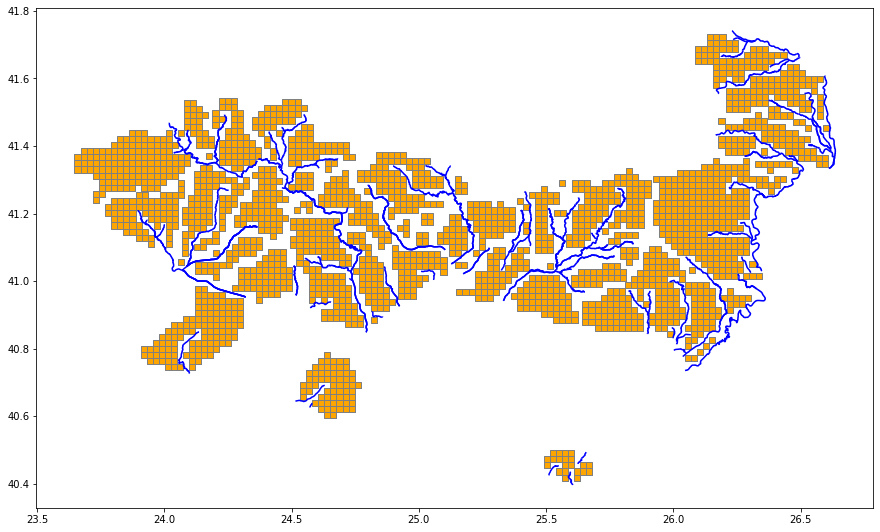

In [22]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [23]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 22


In [24]:
if (len(lau1_units) != len(grid_lau1)):
    delta = [item for item in lau1_units if item not in grid_lau1]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['lau1'] = lost_lau1['lau1']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [25]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [26]:
nuts2_grid

,geometry,lau1,x,y
0,"POLYGON ((24.91839 41.03638, 24.91839 41.05435...",αβδηρων,24.90650,41.04536
1,"POLYGON ((24.91839 41.05435, 24.91839 41.07231...",αβδηρων,24.90650,41.06333
2,"POLYGON ((24.91839 41.07231, 24.91839 41.09028...",αβδηρων,24.90650,41.08130
3,"POLYGON ((24.91839 41.09028, 24.91839 41.10825...",αβδηρων,24.90650,41.09926
4,"POLYGON ((24.94217 40.94655, 24.94217 40.96451...",αβδηρων,24.93028,40.95553
...,...,...,...,...
2116,"POLYGON ((24.88297 40.91199, 24.88297 40.92995...",τοπειρου,24.87109,40.92097
2117,"POLYGON ((24.88297 40.92995, 24.88297 40.94792...",τοπειρου,24.87109,40.93894
2118,"POLYGON ((24.88297 40.94792, 24.88297 40.96589...",τοπειρου,24.87109,40.95690
2119,"POLYGON ((24.88297 40.96589, 24.88297 40.98385...",τοπειρου,24.87109,40.97487


In [27]:
if (len(lau1_units) != len(grid_lau1)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [28]:
nuts2_grid['nuts2'] = 'ανατολικης μακεδονιας και θρακης'

In [29]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [30]:
nuts2_grid

,shape,lau1,x,y,nuts2
0,"POLYGON ((24.91839 41.03638, 24.91839 41.05435...",αβδηρων,24.90650,41.04536,ανατολικης μακεδονιας και θρακης
1,"POLYGON ((24.91839 41.05435, 24.91839 41.07231...",αβδηρων,24.90650,41.06333,ανατολικης μακεδονιας και θρακης
2,"POLYGON ((24.91839 41.07231, 24.91839 41.09028...",αβδηρων,24.90650,41.08130,ανατολικης μακεδονιας και θρακης
3,"POLYGON ((24.91839 41.09028, 24.91839 41.10825...",αβδηρων,24.90650,41.09926,ανατολικης μακεδονιας και θρακης
4,"POLYGON ((24.94217 40.94655, 24.94217 40.96451...",αβδηρων,24.93028,40.95553,ανατολικης μακεδονιας και θρακης
...,...,...,...,...,...
2116,"POLYGON ((24.88297 40.91199, 24.88297 40.92995...",τοπειρου,24.87109,40.92097,ανατολικης μακεδονιας και θρακης
2117,"POLYGON ((24.88297 40.92995, 24.88297 40.94792...",τοπειρου,24.87109,40.93894,ανατολικης μακεδονιας και θρακης
2118,"POLYGON ((24.88297 40.94792, 24.88297 40.96589...",τοπειρου,24.87109,40.95690,ανατολικης μακεδονιας και θρακης
2119,"POLYGON ((24.88297 40.96589, 24.88297 40.98385...",τοπειρου,24.87109,40.97487,ανατολικης μακεδονιας και θρακης


In [31]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [32]:
nuts2_grid_points

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((24.91839 41.03638, 24.91839 41.05435...",αβδηρων,24.90650,41.04536,ανατολικης μακεδονιας και θρακης,POINT (24.90650 41.04536)
1,"POLYGON ((24.91839 41.05435, 24.91839 41.07231...",αβδηρων,24.90650,41.06333,ανατολικης μακεδονιας και θρακης,POINT (24.90650 41.06333)
2,"POLYGON ((24.91839 41.07231, 24.91839 41.09028...",αβδηρων,24.90650,41.08130,ανατολικης μακεδονιας και θρακης,POINT (24.90650 41.08130)
3,"POLYGON ((24.91839 41.09028, 24.91839 41.10825...",αβδηρων,24.90650,41.09926,ανατολικης μακεδονιας και θρακης,POINT (24.90650 41.09926)
4,"POLYGON ((24.94217 40.94655, 24.94217 40.96451...",αβδηρων,24.93028,40.95553,ανατολικης μακεδονιας και θρακης,POINT (24.93028 40.95553)
...,...,...,...,...,...,...
2116,"POLYGON ((24.88297 40.91199, 24.88297 40.92995...",τοπειρου,24.87109,40.92097,ανατολικης μακεδονιας και θρακης,POINT (24.87109 40.92097)
2117,"POLYGON ((24.88297 40.92995, 24.88297 40.94792...",τοπειρου,24.87109,40.93894,ανατολικης μακεδονιας και θρακης,POINT (24.87109 40.93894)
2118,"POLYGON ((24.88297 40.94792, 24.88297 40.96589...",τοπειρου,24.87109,40.95690,ανατολικης μακεδονιας και θρακης,POINT (24.87109 40.95690)
2119,"POLYGON ((24.88297 40.96589, 24.88297 40.98385...",τοπειρου,24.87109,40.97487,ανατολικης μακεδονιας και θρακης,POINT (24.87109 40.97487)


<AxesSubplot:>

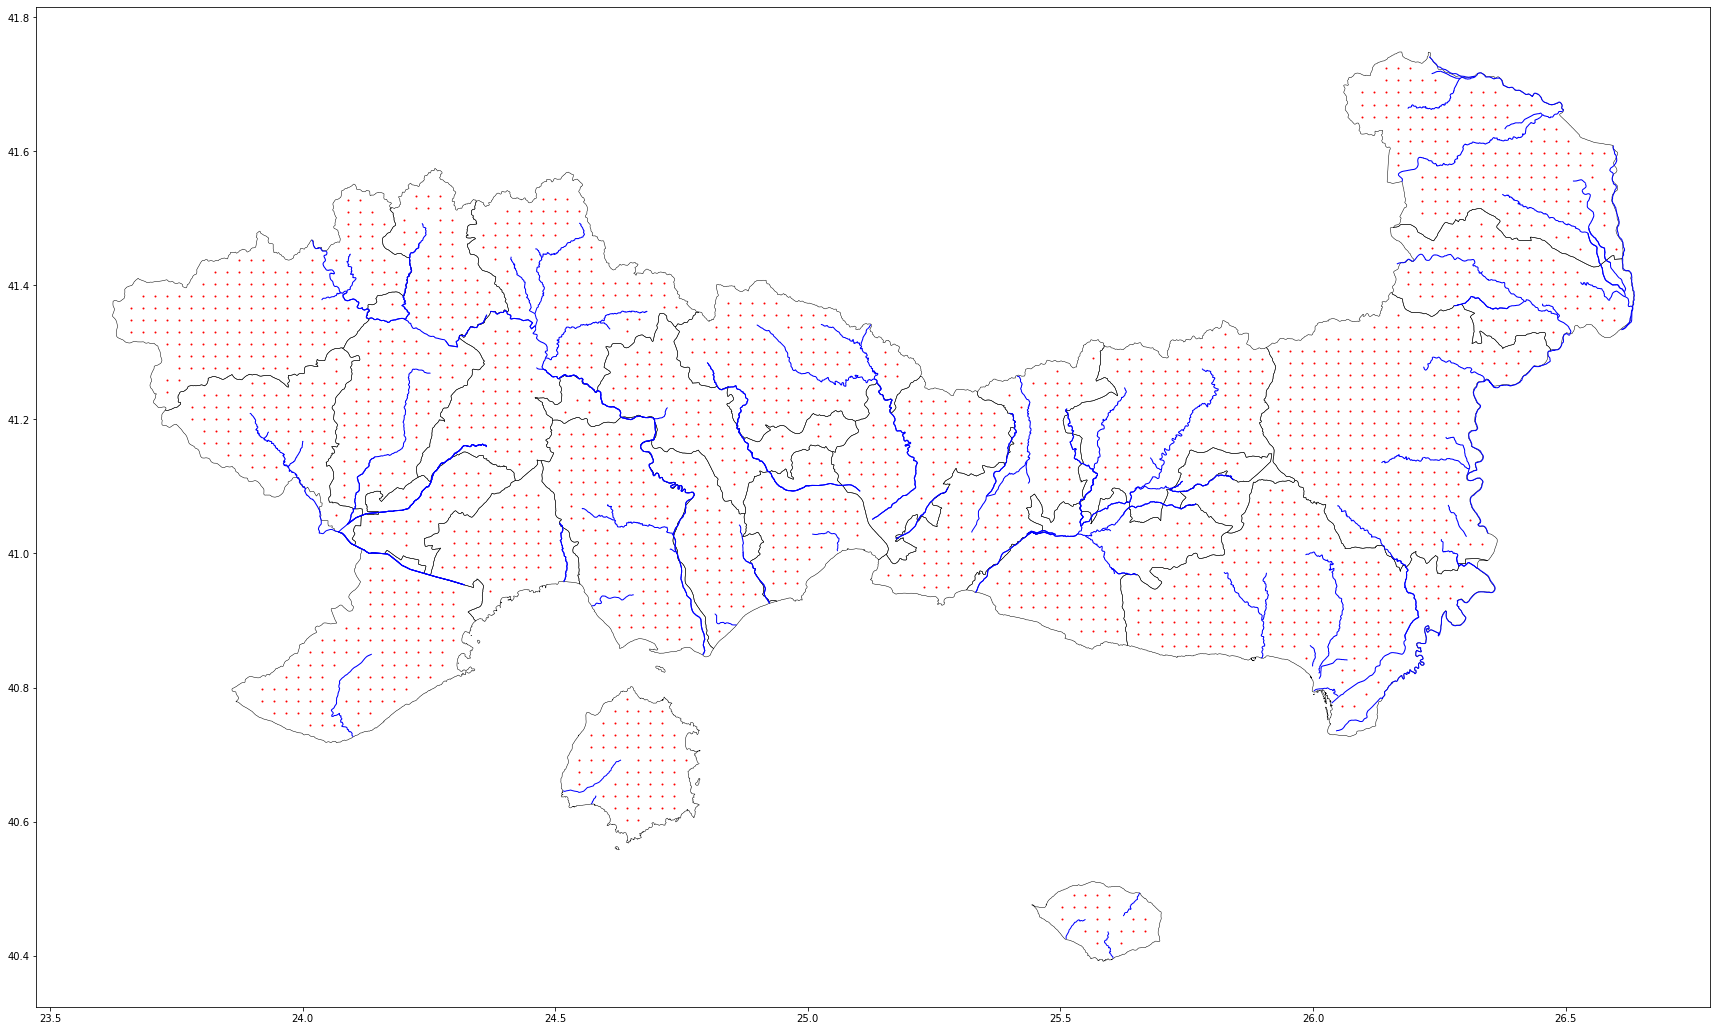

In [33]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [34]:
value_counts = nuts2_grid['lau1'].value_counts().sort_values()

In [35]:
arr = value_counts.values

In [36]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [37]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [38]:
value_counts_target

σαμοθρακης           1
δοξατου              1
τοπειρου             2
αβδηρων              3
καβαλας              3
ξανθης               3
θασου                4
ιασμου               4
προσοτσανης          4
διδυμοτειχου         4
κομοτηνης            5
μυκης                5
μαρωνειας σαπων      5
αρριανων             6
νεστου               7
παγγαιου             7
δραμας               8
παρανεστιου          9
ορεστιαδας           9
κατω νευροκοπιου    10
αλεξανδρουπολης     12
σουφλιου            16
dtype: int32

In [39]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: σαμοθρακης || Value: 21 || Target Value: 1
Index: δοξατου || Value: 28 || Target Value: 1
Index: τοπειρου || Value: 47 || Target Value: 2
Index: αβδηρων || Value: 50 || Target Value: 3
Index: καβαλας || Value: 54 || Target Value: 3
Index: ξανθης || Value: 63 || Target Value: 3
Index: θασου || Value: 65 || Target Value: 4
Index: ιασμου || Value: 67 || Target Value: 4
Index: προσοτσανης || Value: 71 || Target Value: 4
Index: διδυμοτειχου || Value: 72 || Target Value: 4
Index: κομοτηνης || Value: 82 || Target Value: 5
Index: μυκης || Value: 84 || Target Value: 5
Index: μαρωνειας σαπων || Value: 90 || Target Value: 5
Index: αρριανων || Value: 104 || Target Value: 6
Index: νεστου || Value: 109 || Target Value: 7
Index: παγγαιου || Value: 118 || Target Value: 7
Index: δραμας || Value: 127 || Target Value: 8
Index: παρανεστιου || Value: 143 || Target Value: 9
Index: ορεστιαδας || Value: 146 || Target Value: 9
Index: κατω νευροκοπιου || Value: 157 || Target Value: 10
Index: αλεξανδρουπο

In [40]:
to_remove = pd.Series(data=points, index=idx)

In [41]:
to_remove

σαμοθρακης           20
δοξατου              27
τοπειρου             45
αβδηρων              47
καβαλας              51
ξανθης               60
θασου                61
ιασμου               63
προσοτσανης          67
διδυμοτειχου         68
κομοτηνης            77
μυκης                79
μαρωνειας σαπων      85
αρριανων             98
νεστου              102
παγγαιου            111
δραμας              119
παρανεστιου         134
ορεστιαδας          137
κατω νευροκοπιου    147
αλεξανδρουπολης     172
σουφλιου            223
dtype: int64

In [42]:
indicies_to_remove = []

for municipality, points in to_remove.iteritems():
    indicies = nuts2_grid.loc[nuts2_grid['lau1'] ==  municipality].index.tolist()
    to_removed = random.sample(indicies, points)
    for item in to_removed:
        indicies_to_remove.append(item)

nuts2_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
nuts2_grid.reset_index(inplace = True, drop = True)

In [43]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

<AxesSubplot:>

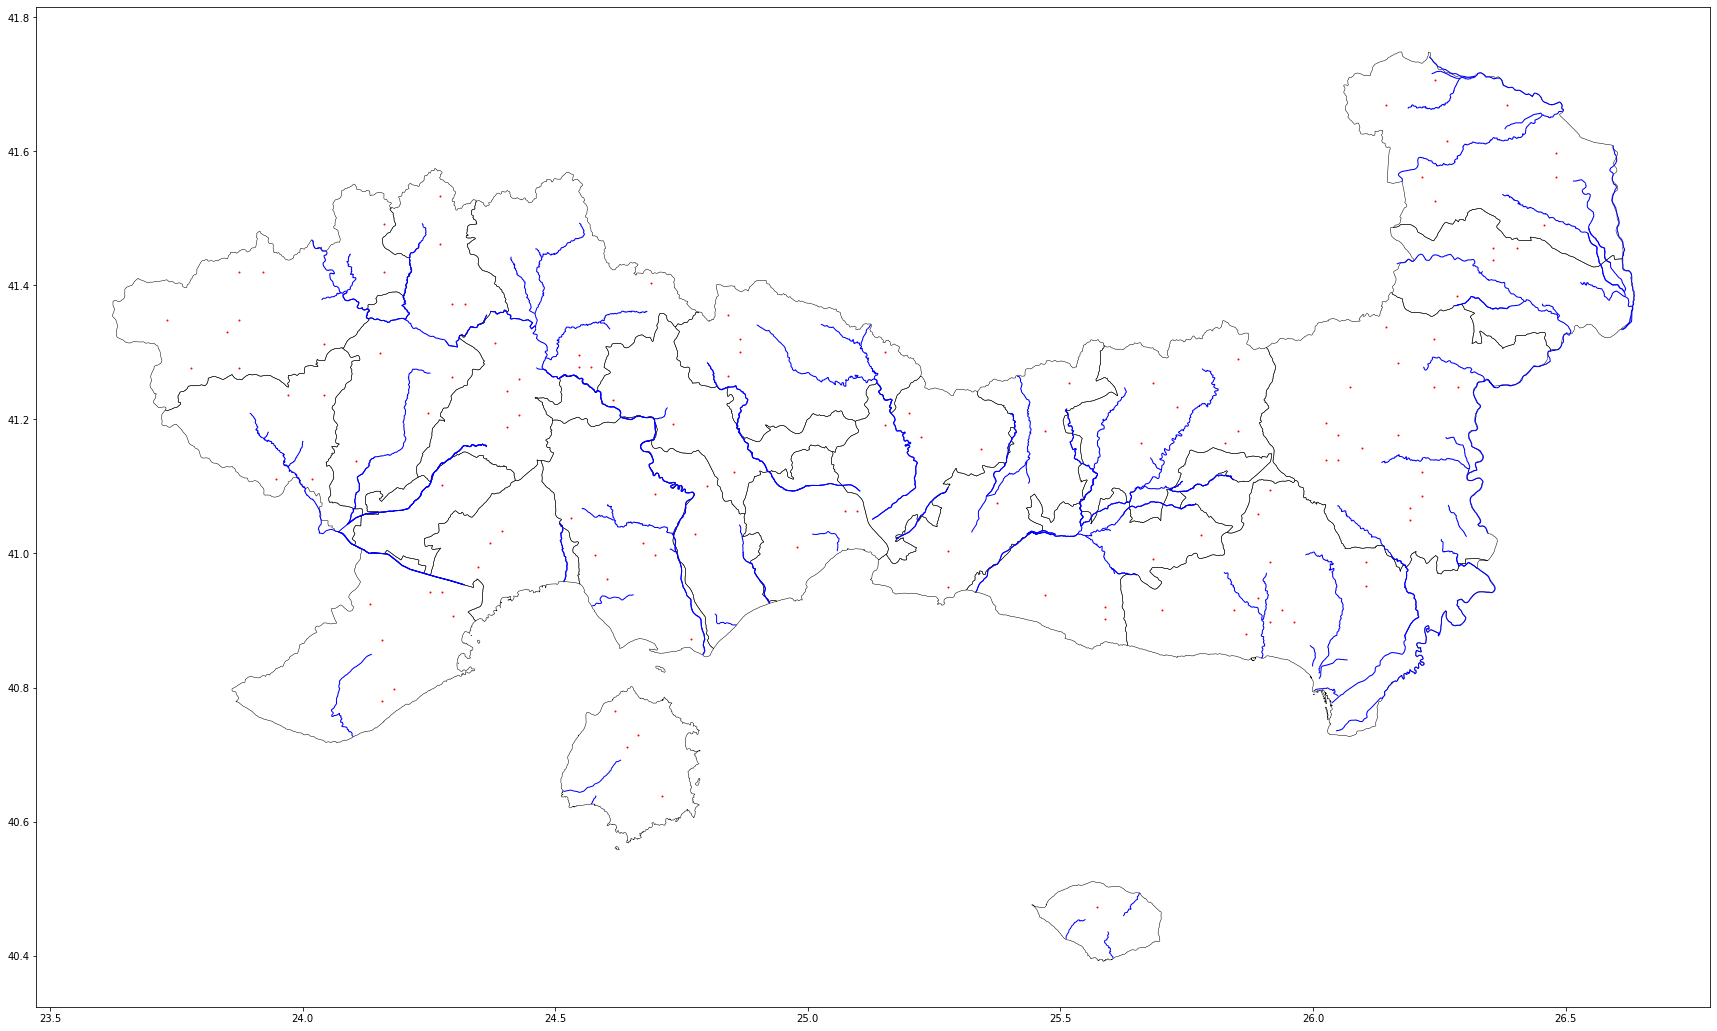

In [44]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [45]:
len(nuts2_grid['lau1'].unique())

22

In [46]:
nuts2_grid

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((24.98973 41.00045, 24.98973 41.01841...",αβδηρων,24.97784,41.00943,ανατολικης μακεδονιας και θρακης,POINT (24.97784 41.00943)
1,"POLYGON ((25.08485 41.05435, 25.08485 41.07231...",αβδηρων,25.07296,41.06333,ανατολικης μακεδονιας και θρακης,POINT (25.07296 41.06333)
2,"POLYGON ((25.10863 41.05435, 25.10863 41.07231...",αβδηρων,25.09674,41.06333,ανατολικης μακεδονιας και θρακης,POINT (25.09674 41.06333)
3,"POLYGON ((25.71373 40.90646, 25.71373 40.92443...",αλεξανδρουπολης,25.70187,40.91545,ανατολικης μακεδονιας και θρακης,POINT (25.70187 40.91545)
4,"POLYGON ((25.85598 40.90646, 25.85598 40.92443...",αλεξανδρουπολης,25.84412,40.91545,ανατολικης μακεδονιας και θρακης,POINT (25.84412 40.91545)
...,...,...,...,...,...,...
123,"POLYGON ((26.25095 41.23903, 26.25095 41.25700...",σουφλιου,26.23905,41.24801,ανατολικης μακεδονιας και θρακης,POINT (26.23905 41.24801)
124,"POLYGON ((26.25095 41.31090, 26.25095 41.32886...",σουφλιου,26.23905,41.31988,ανατολικης μακεδονιας και θρακης,POINT (26.23905 41.31988)
125,"POLYGON ((26.29854 41.23903, 26.29854 41.25700...",σουφλιου,26.28664,41.24801,ανατολικης μακεδονιας και θρακης,POINT (26.28664 41.24801)
126,"POLYGON ((24.78795 41.01979, 24.78795 41.03775...",τοπειρου,24.77607,41.02877,ανατολικης μακεδονιας και θρακης,POINT (24.77607 41.02877)


In [47]:
final_grid = nuts2_grid[['nuts2', 'lau1', 'x', 'y']].sort_values(by=['lau1'])

In [48]:
final_grid

,nuts2,lau1,x,y
0,ανατολικης μακεδονιας και θρακης,αβδηρων,24.97784,41.00943
1,ανατολικης μακεδονιας και θρακης,αβδηρων,25.07296,41.06333
2,ανατολικης μακεδονιας και θρακης,αβδηρων,25.09674,41.06333
13,ανατολικης μακεδονιας και θρακης,αλεξανδρουπολης,26.10491,40.95138
12,ανατολικης μακεδονιας και θρακης,αλεξανδρουπολης,25.96266,40.89748
...,...,...,...,...
123,ανατολικης μακεδονιας και θρακης,σουφλιου,26.23905,41.24801
124,ανατολικης μακεδονιας και θρακης,σουφλιου,26.23905,41.31988
125,ανατολικης μακεδονιας και θρακης,σουφλιου,26.28664,41.24801
126,ανατολικης μακεδονιας και θρακης,τοπειρου,24.77607,41.02877


In [49]:
final_grid.to_csv(f'data/{NUTS0}_{NUTS2}_Grid.csv', encoding=enc, index = False)